Apertura del archivo

# ¡Hola Manuel!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>

**Es un gusto acompañarte en este proceso, ¡empecemos!**

In [1]:
import pandas as pd # importar librería pandas
import numpy as np # importar librería numpy
from matplotlib import pyplot as plt #importar librería matplotlib
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("/datasets/games.csv")
df.info()
print(df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
                        Name Platform  Year_of_Release         Genre  \
0                 Wii Sports      Wii           2006.0        Sports   
1          Super Mario Bros.      NES           1985.0      Platform   
2             Mario Kart 

Preparación de datos

In [3]:
# Reemplazar los nombres de las columnas a minúsculas
df = df.rename(columns=str.lower)
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [4]:
# Conversión de los datos en los tipos necesarios, explicando el porqué
df.info()
print(df[df['year_of_release'].isna()]) # no se puede modificar porque tiene valores nulos, por eso la variable sale flotante

print("Datos ausentes por filas:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
                                    name platform  year_of_release  \
183                      Madden NFL 2004      PS2              NaN   
377                     FIFA Soccer 2004      PS2              NaN   
456           LEGO Batman: The 

Según esto no podemos cambiar el tipo de las filas que deberían estar en números enteros por la presencia de valores ausentes

In [5]:
#df.groupby('platform')['year_of_release'].describe()

In [6]:
# Tratamiento de valores ausentes
df = df.dropna(subset=['name', 'genre']) # columnas name y genre al tener pocos valores ausentes se procede a eliminar
df['year_of_release'] = df.groupby('platform')['year_of_release'].transform(lambda x: x.fillna(x.median())) # se reemplazan los valores ausentes por la mediana 
# del año de publicación de cada una de las plataformas para tener un valor cercano
df['rating'] = df['rating'].fillna('unclassified') # para reemplazar los datos ausentes por "sin clasificar"
df['critic_score'] = df['critic_score'].fillna('tbd') # para reemplazar los datos ausentes a "por definir"
df['user_score'] = df['user_score'].fillna('tbd') # para reemplazar los datos ausentes a "por definir"

df = df.reset_index(drop=True) # se reinician los índices

print("Datos ausentes por filas:")
print(df.isnull().sum())


Datos ausentes por filas:
name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: int64


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente! Hiciste un buen uso de los metodos para estandarizar los encabezados del dataset, además la conversión de tipo y el reemplazo del valor atipico 'tbt' me parece muy apropiado para permitir el manejo de los datos. 
</div>

Análisis de datos

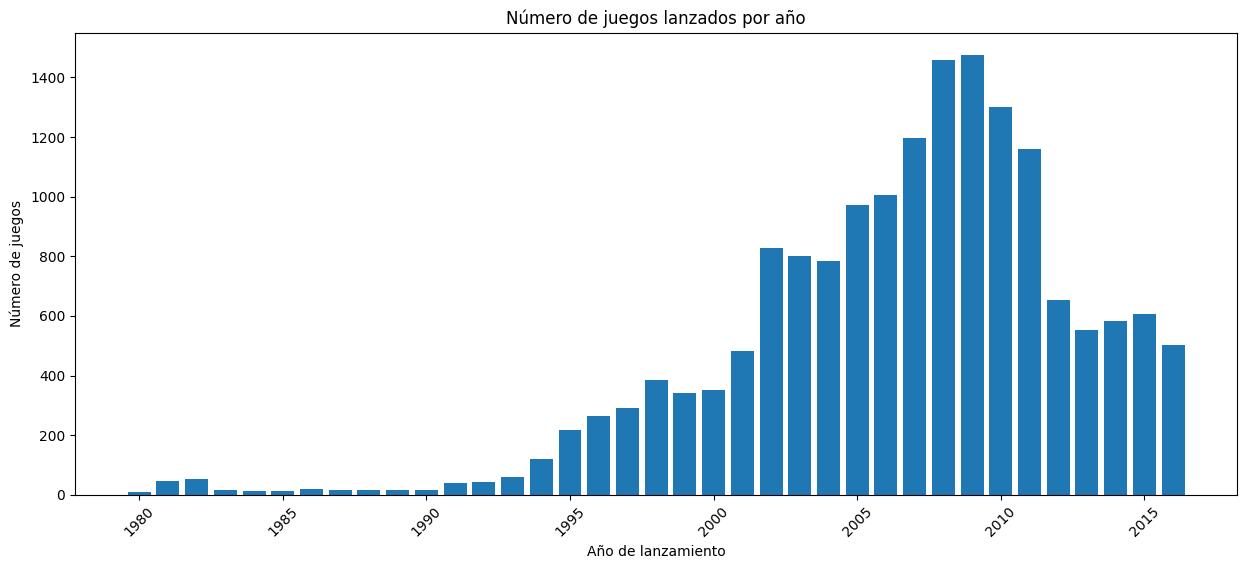

In [8]:
# lanzamiento de juegos por año
games_per_year = df.groupby('year_of_release')['year_of_release'].count()

plt.figure(figsize=(15, 6))
plt.bar(games_per_year.index, games_per_year.values)
plt.title('Número de juegos lanzados por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de juegos')
plt.xticks(rotation=45)
plt.show()

# se observa que en los 80s empezó el interés por los videojuegos teniendo un aumento progresivo, hasta 1983 donde hubo una caída importante de 
#los juegos lanzados, esto pudo ser por el famoso juego de ET para la Atari 2600. Alrededor de 1991 la industria se volvió a recuperar mostrando un
#crecimiento constante, llegando al mayor lanzamiento de videojuegos entre el 2005 y 2010, muy relacionado con el éxito de las consolas de moda de la
#época como Xbox360, PS3, Wii y PC. La distribución de juegos lanzados tiene un comportamiento de sesgo positivo a la izquierda

In [9]:
# Observa cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una 
#distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. 
#¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

platform_count = df['platform'].value_counts(ascending=False)

print("Valor mínimo:")
print(platform_count.min())
print("Valor máximo:")
print(platform_count.max())
print()
print(platform_count)


Valor mínimo:
1
Valor máximo:
2161

PS2     2161
DS      2151
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      430
PS4      392
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
NES       98
GB        98
DC        52
GEN       27
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: platform, dtype: int64


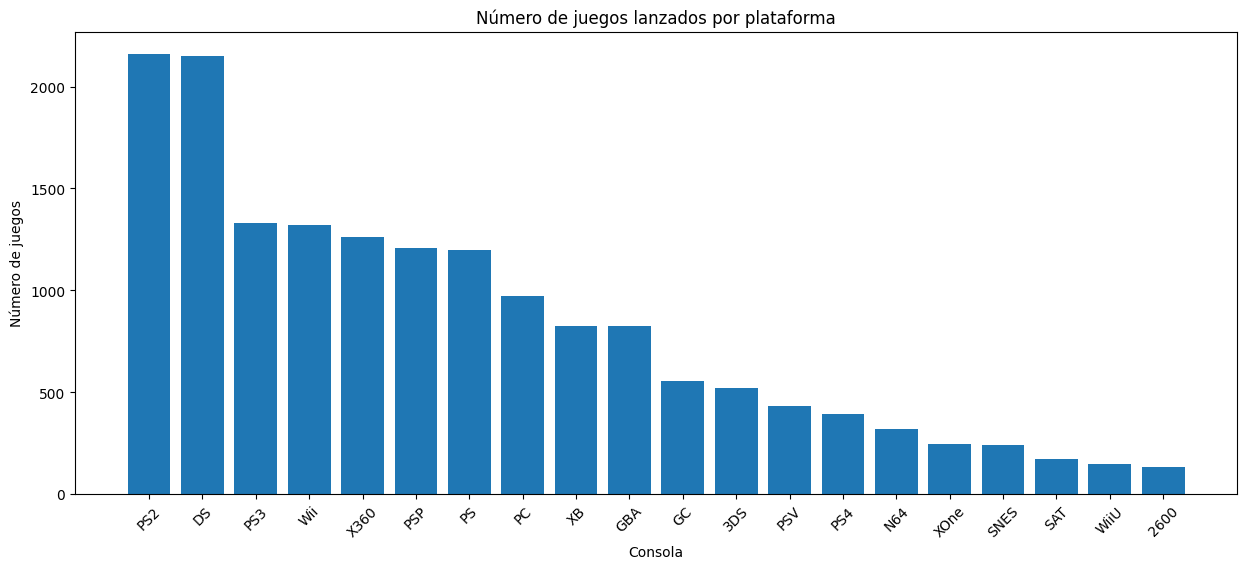

Plataformas eliminadas:
NES     98
GB      98
DC      52
GEN     27
NG      12
SCD      6
WS       6
3DO      3
TG16     2
GG       1
PCFX     1
Name: platform, dtype: int64


In [10]:
platform_filtered = platform_count[platform_count >=100] # mínimo 100 juegos

plt.figure(figsize=(15, 6))
plt.bar(platform_filtered.index, platform_filtered.values)
plt.title('Número de juegos lanzados por plataforma')
plt.xlabel('Consola')
plt.ylabel('Número de juegos')
plt.xticks(rotation=45)
plt.show()

print("Plataformas eliminadas:")
print(platform_count[platform_count <=100])

<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Muy buen trabajo con la presentación de los datos de los juegos lanzados y la diferenciación por plataformas. 
</div>

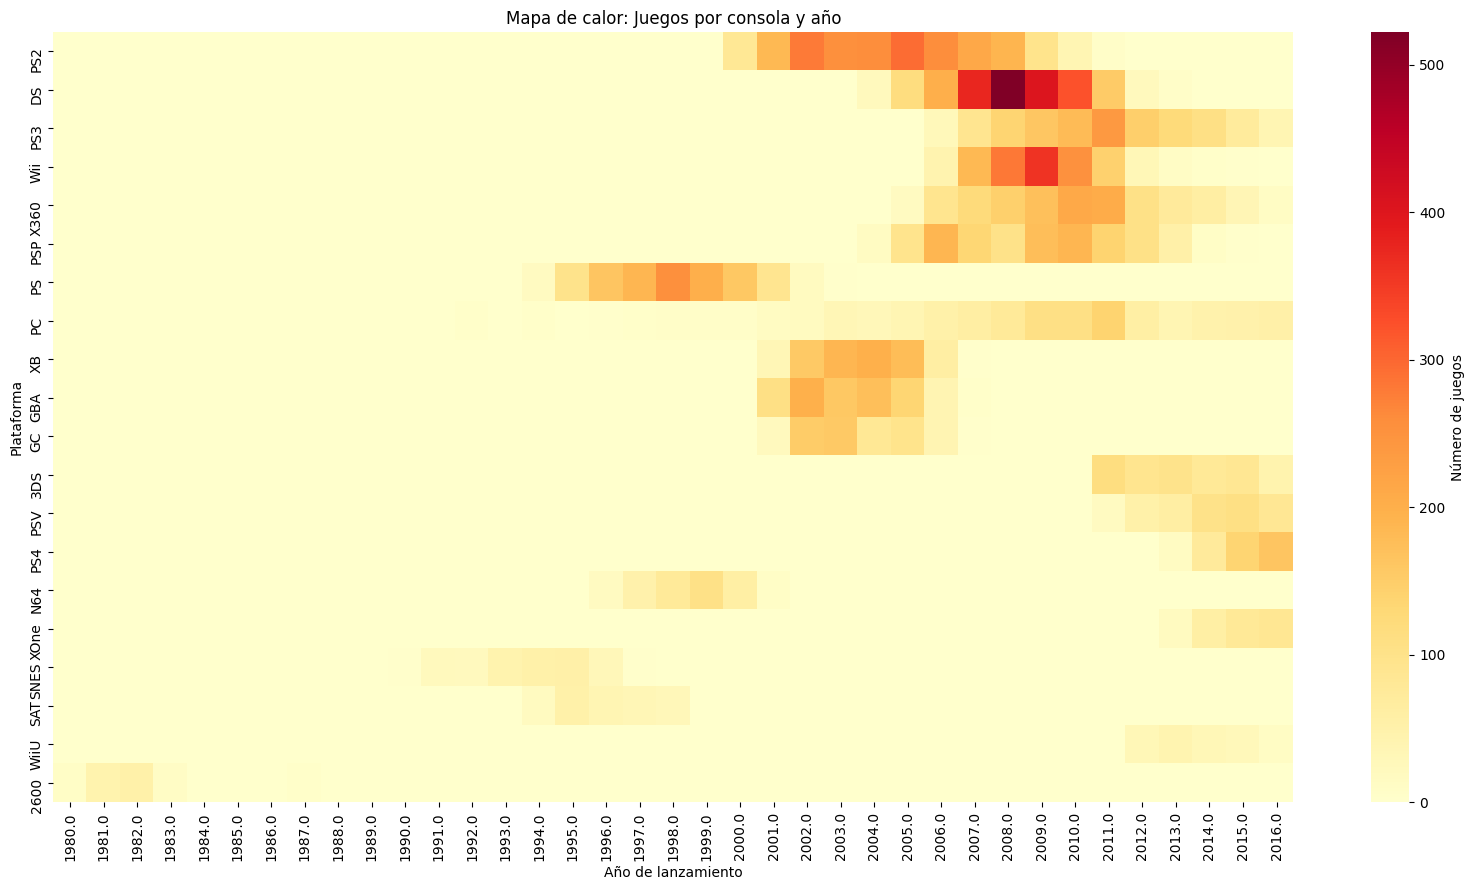

In [11]:
#¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? Elige varias plataformas potencialmente rentables.

# Crear tabla de contingencia: años vs plataformas
platform_year = df.groupby(['year_of_release', 'platform']).size().unstack(fill_value=0)


# Seleccionar las plataformas más importantes (las que tienen más de 100 juegos)
top_platforms = platform_count[platform_count >= 100].index


# Crear matriz para el mapa de calor
platform_year_top = platform_year[top_platforms]

plt.figure(figsize=(20, 10))
sns.heatmap(platform_year_top.T, cmap='YlOrRd', cbar_kws={'label': 'Número de juegos'}) # .T para transponer la matriz
# cmap='YlOrDd' define la paleta de colores (yellow-orange-red), cbar_kws añade una etiqueta a la barra de colores
plt.title('Mapa de calor: Juegos por consola y año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Plataforma')
plt.show()

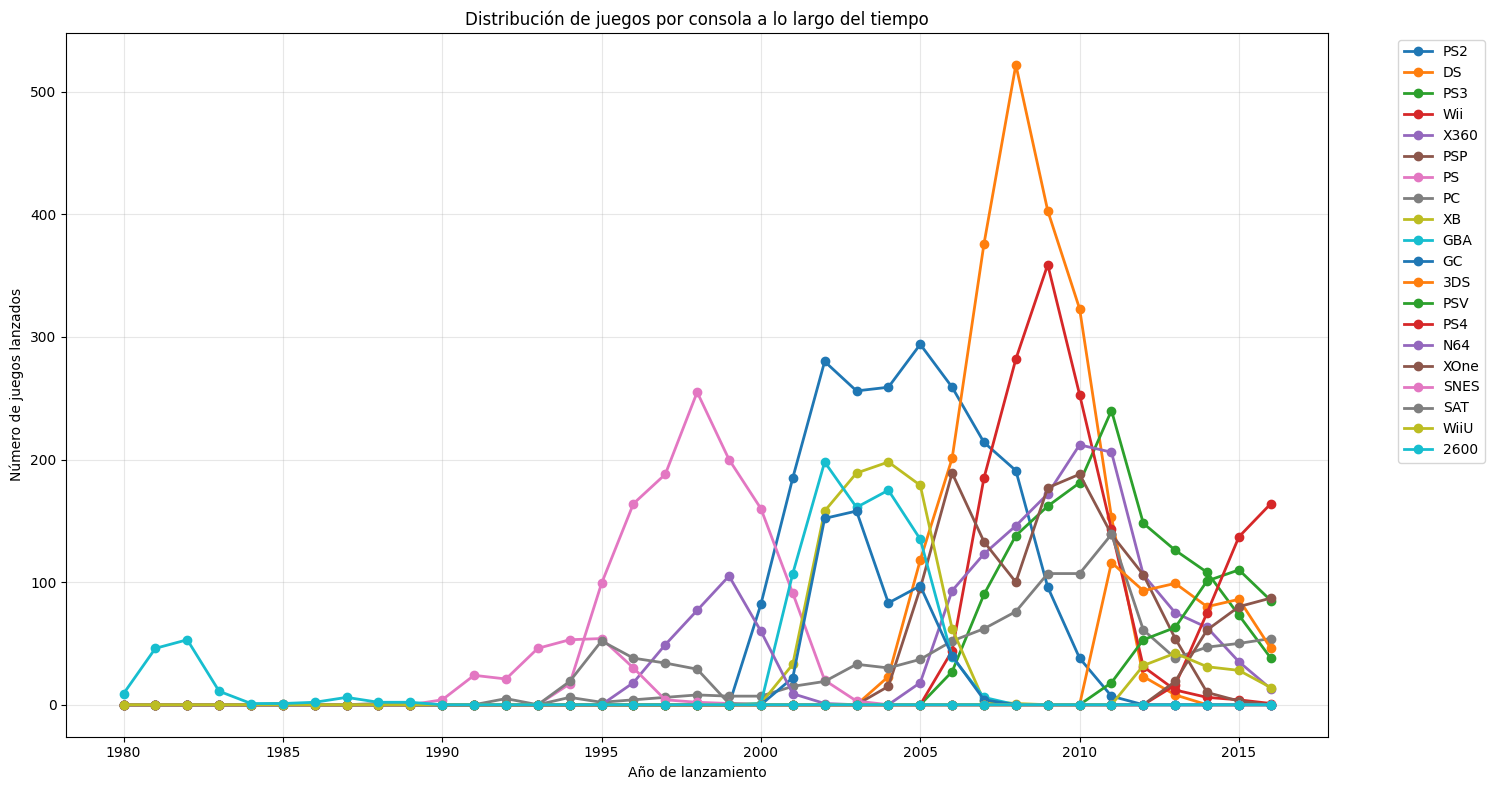

In [12]:
plt.figure(figsize=(15, 8))
for platform in top_platforms:
    if platform in platform_year.columns:
        plt.plot(platform_year.index, platform_year[platform], 
                marker='o', label=platform, linewidth=2)

plt.title('Distribución de juegos por consola a lo largo del tiempo')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de juegos lanzados')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Según lo observado, aunque el mayor auge de lanzamiento de juegos fue el 2009 y 2010, debido a la vida media de las consolas se tendrán en cuenta las que 
todavía tienen lanzamientos de juegos a partir del 2013 como lo son: PS3, Xbox 360, PC, 3DS, PS vita, PS4, Xbox One y Wii U 

<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Genial! Me gustó mucho el mapa de calor que realizaste, y la interpretación y decisión del rango de tiempo desde el 2013. Buen trabajo!
</div>

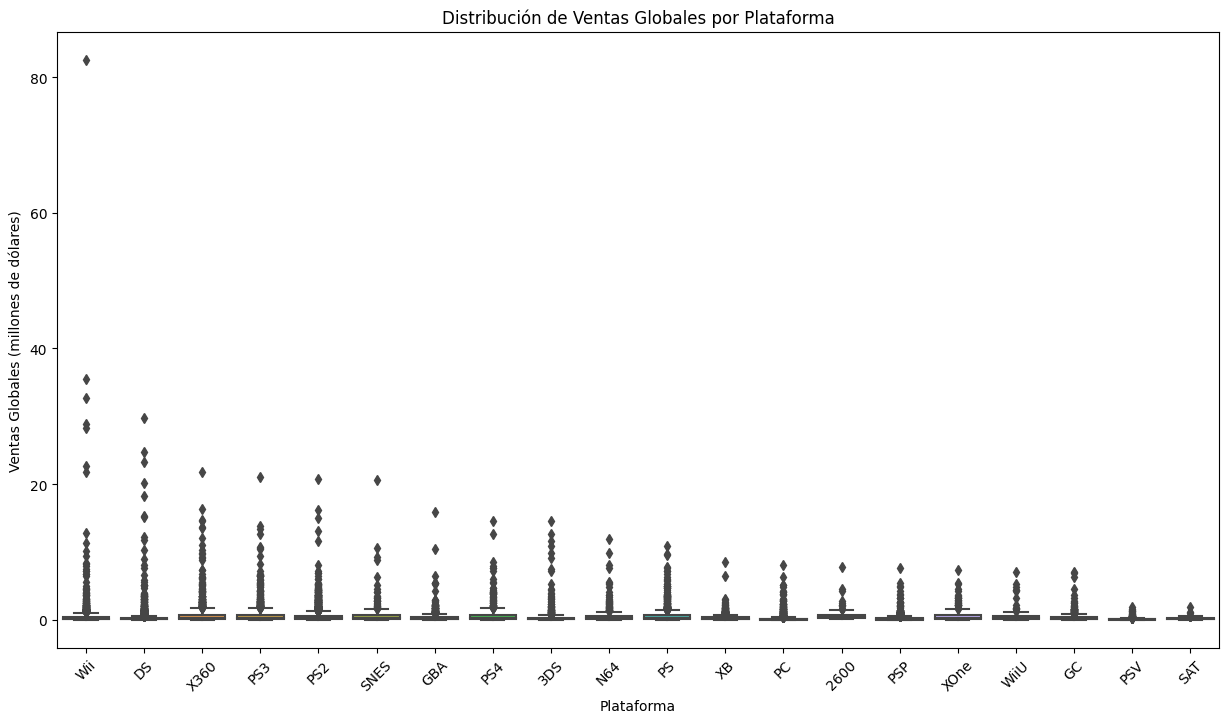

In [13]:
#Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma. ¿Son significativas las 
#diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos.

# Crear columna de ventas globales sumando todas las regiones
df['global_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

df_filtered = df[df['platform'].isin(top_platforms)] # se filtra para las consolas con mas de 100 juegos

# gráfico de cajas y bigotes
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_filtered, x='platform', y='global_sales')
plt.title('Distribución de Ventas Globales por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Globales (millones de dólares)')
plt.xticks(rotation=45)
plt.show()

El gráfico muestra que las plataformas evaluadas presentan muchos valores atípicos, lo que hace que consolas como la Nintendo Wii y DS queden como las de mayores ventas. Según se observa, la Nintendo Wii inclusive presenta un valor atípico que supera los 80 millones de dólares (82.593 millones).

Datos de Xbox 360:
Total de juegos: 1262
Critic_score válidos: 916
User_score válidos: 966
Juegos con ambas reseñas válidas: 881


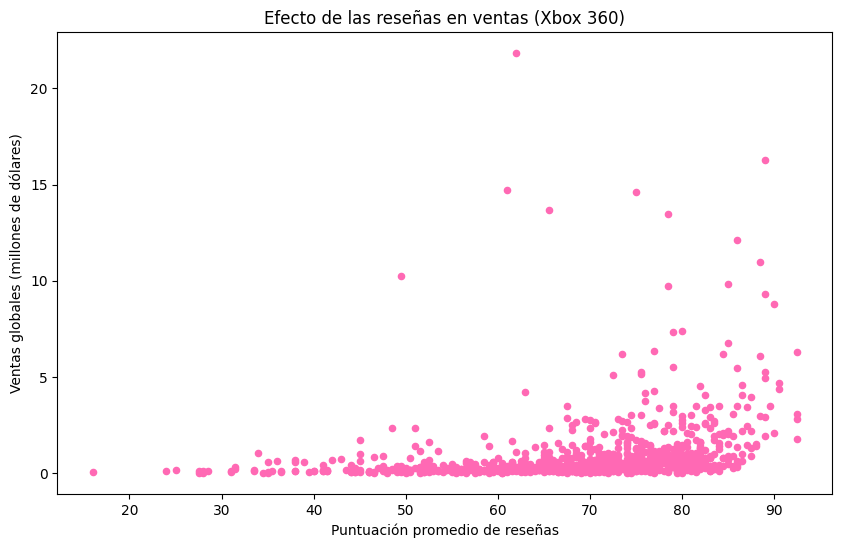

Nivel de correlación entre la puntuación promedio y las ventas globales de juegos: 0.28515126725241724


In [14]:
#Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de 
#dispersión y calcula la #correlación entre las reseñas y las ventas. Saca conclusiones.


df_filtered_360 = df_filtered[df_filtered['platform'] == 'X360']

# Verificar cuántos datos válidos tienes para Xbox 360
print("Datos de Xbox 360:")
print(f"Total de juegos: {len(df_filtered_360)}")
print(f"Critic_score válidos: {len(df_filtered_360[df_filtered_360['critic_score'] != 'tbd'])}")
print(f"User_score válidos: {len(df_filtered_360[df_filtered_360['user_score'] != 'tbd'])}")

# Filtrar solo los datos con reseñas válidas (no 'tbd')
df_xbox_clean = df_filtered_360[
    (df_filtered_360['critic_score'] != 'tbd') & 
    (df_filtered_360['user_score'] != 'tbd')
].copy() # copy para crear una copia independiente del dataframe filtrado

# Convertir las puntuaciones a numéricas
df_xbox_clean['critic_score'] = pd.to_numeric(df_xbox_clean['critic_score'])
df_xbox_clean['user_score'] = pd.to_numeric(df_xbox_clean['user_score'])
print(f"Juegos con ambas reseñas válidas: {len(df_xbox_clean)}")

# Estandarizar datos a 100
df_xbox_clean['user_score'] = df_xbox_clean['user_score']*10

# Promediar puntuaciones
df_xbox_clean['mean_score'] = (df_xbox_clean['critic_score'] + df_xbox_clean['user_score']) / 2


#print(df_xbox_clean)

df_xbox_clean.plot(x='mean_score', y='global_sales', 
                   kind='scatter',  
                   title='Efecto de las reseñas en ventas (Xbox 360)', 
                   color='hotpink',
                   figsize=(10, 6),
                   xlabel="Puntuación promedio de reseñas", 
                   ylabel="Ventas globales (millones de dólares)")
plt.show()

correlation = df_xbox_clean['mean_score'].corr(df_xbox_clean['global_sales'])
print(f"Nivel de correlación entre la puntuación promedio y las ventas globales de juegos: {correlation}")

Se puede observar que hay una correlación positiva entre las dos variables evaluadas, aunque es débil ya que su valor es de 0.28. 
Esto indica que aunque las puntuaciones pueden afectar las ventas de los juegos, no es el único factor que el consumidor tiene en cuenta,
algo que es muy cierto y se puede evidenciar con algunos juegos ya que las puntuaciones parecen estar sesgadas.

<div class="alert alert-block alert-warning"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Buen trabajo del calculo de correlacion entre las reseñas y las ventas. Solo te recuerdo que la idea es comparar entre reseñas de críticos expertos y reseñas de usuarios para ver cual de la dos tiene la mayor influencia. 
</div>

In [15]:
#Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.
# filtro las plataformas distintas de Xbox 360
df_no_x360 = df_filtered[df_filtered['platform'] != 'X360']

# uno los dataframes con respecto a los nombres de los juegos de Xbox 360
df_other_platforms = df_no_x360.merge(df_filtered_360, on='name',
                                     suffixes=('_other_platforms', '_xbox360')) 

# Filtrar solo los datos con reseñas válidas (no 'tbd')
df_other_platforms_clean = df_other_platforms[
    (df_other_platforms['critic_score_other_platforms'] != 'tbd') & 
    (df_other_platforms['user_score_other_platforms'] != 'tbd')].copy() # copy para crear una copia independiente del dataframe filtrado

# Convertir las puntuaciones a numéricas
df_other_platforms_clean['critic_score_other_platforms'] = pd.to_numeric(df_other_platforms_clean['critic_score_other_platforms'])
df_other_platforms_clean['user_score_other_platforms'] = pd.to_numeric(df_other_platforms_clean['user_score_other_platforms'])
print(f"Juegos con ambas reseñas válidas: {len(df_other_platforms_clean)}")

# Estandarizar datos a 100
df_other_platforms_clean['user_score_other_platforms'] = df_other_platforms_clean['user_score_other_platforms']*10

# Promediar puntuaciones
df_other_platforms_clean['mean_score_other_platforms'] = (df_other_platforms_clean['critic_score_other_platforms'] + 
                                                          df_other_platforms_clean['user_score_other_platforms']) / 2

correlation_other_platforms = df_other_platforms_clean['mean_score_other_platforms'].corr(df_other_platforms_clean['global_sales_other_platforms'])
print(f"Nivel de correlación entre la puntuación promedio y las ventas globales de juegos en plataformas distintas a Xbox 360: {correlation_other_platforms}")


Juegos con ambas reseñas válidas: 1619
Nivel de correlación entre la puntuación promedio y las ventas globales de juegos en plataformas distintas a Xbox 360: 0.23440216059161328


El nivel de correlación entre la puntuación promedio (crítica y usuarios) y las ventas globales de los juegos en plataformas
diferentes a Xbox360 presenta una correlación positiva débil de 0.2344, que a comparación con la correlación obtenida para
la venta de juegos en la consola de Microsoft es menor (el valor nos había dado 0.28)

In [16]:
#Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? 
#¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

# Análisis de géneros por ventas
genre_analysis = df_filtered.groupby('genre').agg({
    'global_sales': ['count', 'sum', 'mean', 'median'],
    'name': 'count'
}).round(2) #redondear a dos decimales

# Aplanar los nombres de las columnas
genre_analysis.columns = ['num_juegos', 'ventas_totales', 'ventas_promedio', 'ventas_mediana', 'count_names']
genre_analysis = genre_analysis.drop('count_names', axis=1)  # eliminar columna duplicada

print("Análisis de géneros:")
print(genre_analysis.sort_values('ventas_totales', ascending=False))


Análisis de géneros:
              num_juegos  ventas_totales  ventas_promedio  ventas_mediana
genre                                                                    
Action              3344         1703.49             0.51            0.19
Sports              2311         1288.49             0.56            0.22
Shooter             1310         1015.16             0.77            0.23
Role-Playing        1453          825.28             0.57            0.17
Misc                1737          785.45             0.45            0.16
Racing              1235          711.36             0.58            0.18
Platform             830          657.57             0.79            0.24
Fighting             817          431.85             0.53            0.21
Simulation           866          385.88             0.45            0.15
Adventure           1282          213.17             0.17            0.05
Puzzle               550          174.09             0.32            0.10
Strategy         

Se puede ver que si hay una tendencia por los tipos de géneros, siendo los más atractivos para los usuarios los juegos de acción, deporte
y disparos en las ventas globales.

Perfil de ususario para cada región

<Figure size 1500x800 with 0 Axes>

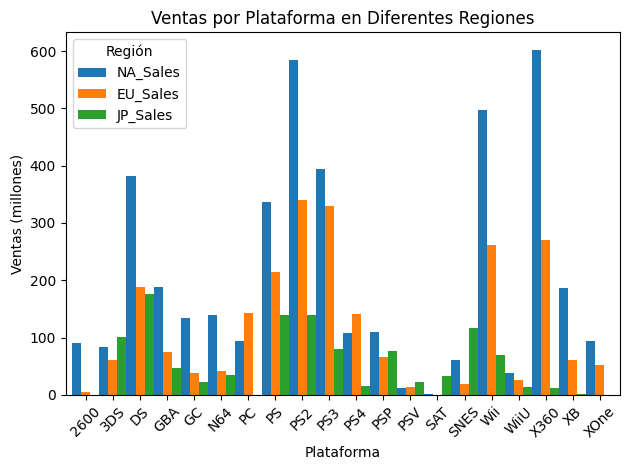

In [17]:
#Para cada región (NA, UE, JP) determina: Las cinco plataformas principales. 
top_platforms_na = df_filtered.groupby('platform')['na_sales'].sum()

top_platforms_eu = df_filtered.groupby('platform')['eu_sales'].sum()

top_platforms_jp = df_filtered.groupby('platform')['jp_sales'].sum()

# Crear DataFrame para facilitar la visualización
platforms_comparison = pd.DataFrame({
    'NA_Sales': top_platforms_na,
    'EU_Sales': top_platforms_eu,
    'JP_Sales': top_platforms_jp
}).fillna(0)

# Gráfico de barras agrupadas
plt.figure(figsize=(15, 8))
platforms_comparison.plot(kind='bar', width=1)
plt.title('Ventas por Plataforma en Diferentes Regiones')
plt.xlabel('Plataforma')
plt.ylabel('Ventas (millones)')
plt.legend(title='Región')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se pueden observar diferencias entre la popularidad de las plataformas según la región. Para cada una este sería el top
Estados Unidos: 
1. XBOX360 
2. PS2 
3. WII 
4. PS3 
5. DS
Europa: 
1. PS2 
2. PS3 
3. XBOX360 
4. WII 
5. PS
Japón:
1. DS
2. PS
3. PS2
4. SNES
5. 3DS

También se puede observar que Norte América tiene un consumo mucho mayor que las demás regiones, siendo por esto una apuesta a la hora de lanzamiento
de juegos. Europa también representa un mercado interesante, aunque no alcanza las ventas similares a Estados Unidos. Hablando de Japón, se nota un
comportamiento más regionalista, donde los consumidores tienden a apoyar a las empresas japonesas que desarrollan videojuegos como Nintendo o Sony, 
casi que omitiendo el consumo de consolas como las de Microsoft.

In [18]:
# Géneros más populares según la región
top_genre_na = df_filtered.groupby('genre')['na_sales'].sum().sort_values(ascending=False)
top_genre_eu = df_filtered.groupby('genre')['eu_sales'].sum().sort_values(ascending=False)
top_genre_jp = df_filtered.groupby('genre')['jp_sales'].sum().sort_values(ascending=False)

print("Géneros más populares en Estados Unidos:")
print(top_genre_na.head())

print("Géneros más populares en Europa:")
print(top_genre_eu.head())

print("Géneros más populares en Japón:")
print(top_genre_jp.head())


Géneros más populares en Estados Unidos:
genre
Action     856.36
Sports     668.95
Shooter    562.81
Misc       401.19
Racing     351.30
Name: na_sales, dtype: float64
Géneros más populares en Europa:
genre
Action     512.90
Sports     372.72
Shooter    315.82
Racing     233.71
Misc       210.59
Name: eu_sales, dtype: float64
Géneros más populares en Japón:
genre
Role-Playing    302.49
Action          150.45
Sports          112.94
Misc             99.60
Platform         85.25
Name: jp_sales, dtype: float64


Comparando la popularidad de los géneros según las regiones, es interesante ver la similaridad entre Estados Unidos y Europa,
donde el top 3 se comparte (acción, deportes, disparos). Con respecto a Japón, si presentan intereses en otros géneros de
videojuegos, principalmente los juegos de rol (seguidos de los de acción y deportes, similares a las otras regiones), 
siendo lógico porque se tiene inclusive un subgénero propio que es el J-RPG, donde se tienen exponentes importantes como Pokemón y Final Fantasy.

<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente análisis por regiones, es bastante interesante el punto que mencionas sobre la particularidad del comportamiento y preferencias de Japón. 
</div>

In [19]:
#Para cada región (NA, UE, JP) Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

df_filtered['rating'].unique()

top_rating_na = df_filtered.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
top_rating_eu = df_filtered.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
top_rating_jp = df_filtered.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

print("Clasificaciones ESRB más populares en Estados Unidos:")
print(top_rating_na.head())

print("Clasificaciones ESRB más populares en Europa:")
print(top_rating_eu.head())

print("Clasificaciones ESRB más populares en Japón:")
print(top_rating_jp.head())


Clasificaciones ESRB más populares en Estados Unidos:
rating
E               1291.97
unclassified     976.26
T                759.23
M                748.48
E10+             353.32
Name: na_sales, dtype: float64
Clasificaciones ESRB más populares en Europa:
rating
E               710.20
unclassified    537.05
M               483.97
T               426.79
E10+            188.52
Name: eu_sales, dtype: float64
Clasificaciones ESRB más populares en Japón:
rating
unclassified    645.95
E               197.86
T               149.04
M                64.19
E10+             40.20
Name: jp_sales, dtype: float64


Revisando clasificaciones ESRB, podemos ver que se tiene un patrón similar entre Estados Unidos y Europa, siendo la clasificación
más popular la E (everyone), a diferencia de Japón que es "sin clasificar". Toca entrar a estudiar más a fondo los datos ya que
la clasificación "sin clasificar" figura en puestos de popularidad alto, por lo que se debe tener un mayor énfasis cuando se vayan 
a obtener estos tipos de datos para poder perfilar a los usuarios.

Prueba de hipótesis

In [20]:
#Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas. Establece tu mismo el valor de umbral alfa.
#Explica:
#— Cómo formulaste las hipótesis nula y alternativa.
#— Qué criterio utilizaste para probar las hipótesis y por qué.

#Repetimos paso anterior para promediar los puntajes pero al df filtrado, no solo a Xbox 360

# Filtrar solo los datos con reseñas válidas (no 'tbd')
df_filtered_clean = df_filtered[
    (df_filtered['critic_score'] != 'tbd') & 
    (df_filtered['user_score'] != 'tbd')
].copy() # copy para crear una copia independiente del dataframe filtrado

# Convertir las puntuaciones a numéricas
df_filtered_clean['critic_score'] = pd.to_numeric(df_filtered_clean['critic_score'])
df_filtered_clean['user_score'] = pd.to_numeric(df_filtered_clean['user_score'])

# Filtrar los datos de PC y de XBox One
xone_scores = df_filtered_clean[df_filtered_clean['platform'] == 'XOne']['user_score']
pc_scores = df_filtered_clean[df_filtered_clean['platform'] == 'PC']['user_score']

# H0 = no hay diferencias entre las calificaciones de los usuarios para las plataformas Xbox One y PC 

alpha = 0.05

t_stat, p_value = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)

print(p_value)
if (p_value < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")


3.462578002314619e-05
Rechazamos la hipótesis nula


La hipótesis nula formulada fue que no hay diferencias entre las calificaciones de los usuarios para las plataformas de XBox One y PC.
Luego de realizar el análisis estadístico de la T-student se puede concluir que se rechaza la hipótesis nula porque el valor es menor al alfa definido
de 0.05 (el resultado fue 3.46e-05)

In [21]:
#Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes. Establece el valor de umbral alfa.
#Explica:
#— Cómo formulaste las hipótesis nula y alternativa.
#— Qué criterio utilizaste para probar las hipótesis y por qué.

# Filtrar los datos de action y sports
action_scores = df_filtered_clean[df_filtered_clean['genre'] == 'Action']['user_score']
sports_scores = df_filtered_clean[df_filtered_clean['genre'] == 'Sports']['user_score']

# H0 las calificaciones promedio de los usuarios para los géneros de acción y deportes son iguales

alpha = 0.05

t_stat, p_value = stats.ttest_ind(action_scores, sports_scores, equal_var=False)

print(p_value)
if (p_value < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

0.8275851824959681
No podemos rechazar la hipótesis nula


In [49]:
df_filtered_clean.corr()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,global_sales
year_of_release,1.000000,-0.021347,0.037078,-0.039696,0.037958,-0.007355,-0.247382,0.001854
na_sales,-0.021347,1.000000,0.840020,0.467726,0.727141,0.234413,0.087385,0.955512
eu_sales,0.037078,0.840020,1.000000,0.519264,0.716431,0.213166,0.056221,0.938686
jp_sales,-0.039696,0.467726,0.519264,1.000000,0.394704,0.145428,0.126221,0.613006
other_sales,0.037958,0.727141,0.716431,0.394704,1.000000,0.192151,0.057984,0.804494
critic_score,-0.007355,0.234413,0.213166,0.145428,0.192151,1.000000,0.580355,0.237893
user_score,-0.247382,0.087385,0.056221,0.126221,0.057984,0.580355,1.000000,0.089213
global_sales,0.001854,0.955512,0.938686,0.613006,0.804494,0.237893,0.089213,1.000000


<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Hiciste un excelente trabajo con las pruebas de hipótesis. Tu eleccion de los tipos de prueba y los niveles de significancia es muy acertada. Además, las justificaciones que proporcionas para interpretar los resultados le dan un completo desarrollo al trabajo. Excelente!


Conlusión general

Fue un proyecto muy enriquecedor, poder agrupar todos los conocimientos adquiridos a lo largo de los primeros seis sprints. Estos
tipos de análisis son valiosos para las empresas para conocer el comportamiento de los consumidores y así definir sus estrategias
de mercadeo por ejemplo. Sabiendo estos resultados, se entiende por qué casi todas las desarrolladoras se enfocan en el mercado
norteamericano, ya que su consumo es mucho mayor en comparación con las otras dos regiones principales (Europa y Japón).

Otro dato interesante es la correlación que puede haber entre las puntuaciones y las ventas globales, que aunque según las regiones 
varía, se puede identificar una correlación positiva. Esto es un punto crítico porque a veces las clasificaciones dadas por la prensa
pueden estar sesgadas y favorecer a las grandes desarrolladoras, dejando los estudios independientes (indie) a un lado.
    
Es importante tener una buena recolección de los datos para que los resultados sean más precisos, como por 
ejemplo con la clasificación de los juegos que estos se pueden ver afectados si tienen una clasificación para mayores de edad. 


<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Has hecho un excelente trabajo. Tus conclusiones son detalladas y muy utiles. Me gustan las recomendaciones estratégicas que propones, este es justo el objetivo que tenemos como científicos de datos en este camino. Sigue así!
</div>